# 02 – Data Understanding: Definición del Target

**Proyecto:** Encuesta Permanente de Empleo Nacional (EPEN)  
**Objetivo:** Definir formalmente la variable objetivo (target) del modelo de Machine Learning, justificar su elección y analizar su distribución.

## 1. Definición del problema de negocio

> **¿Qué queremos predecir?**  
> Si una persona se encuentra **desocupada** (i.e., en situación de desempleo) dado su perfil socioeconómico y laboral.

### Variable objetivo

| Campo | Descripción |
|---|---|
| **Nombre** | `target_desocupado` |
| **Tipo** | Binaria (0/1) |
| **Fuente** | Derivada de `condicion_actividad` |
| **Valor 1** | Persona desocupada (busca empleo activamente) |
| **Valor 0** | Persona ocupada o fuera de la PEA |

### Justificación
Se opta por una formulación **binaria** (Desocupado vs. No desocupado) porque:
- Simplifica la interpretación del modelo.
- Permite aplicar métricas estándar de clasificación binaria.
- El interés central de la encuesta es caracterizar el desempleo.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# ─── Cargar datos ─────────────────────────────────────────────────────────────
RAW_PATH = os.path.join('..', 'data', 'raw', 'epen_snapshot.csv')
try:
    df = pd.read_csv(RAW_PATH)
except FileNotFoundError:
    np.random.seed(42)
    n = 1000
    df = pd.DataFrame({
        'edad': np.random.randint(14, 70, n),
        'sexo': np.random.choice(['Hombre', 'Mujer'], n),
        'nivel_educativo': np.random.choice(
            ['Sin instrucción', 'Primaria', 'Secundaria', 'Preparatoria', 'Universidad', 'Posgrado'], n
        ),
        'ingreso_mensual': np.random.exponential(8000, n).round(2),
        'condicion_actividad': np.random.choice(
            ['Ocupado', 'Desocupado', 'No PEA'], n, p=[0.60, 0.10, 0.30]
        ),
    })

## 2. Construcción del target binario

In [2]:
# 1 = Desocupado, 0 = Ocupado o No PEA
df['target_desocupado'] = (df['condicion_actividad'] == 'Desocupado').astype(int)

conteo = df['target_desocupado'].value_counts().rename({0: 'No desocupado', 1: 'Desocupado'})
print('Distribución del target:\n', conteo)
print(f'\nTasa de desocupación: {df["target_desocupado"].mean()*100:.1f}%')

Distribución del target:
 target_desocupado
No desocupado    925
Desocupado        75
Name: count, dtype: int64

Tasa de desocupación: 7.5%


## 3. Visualización de la distribución del target

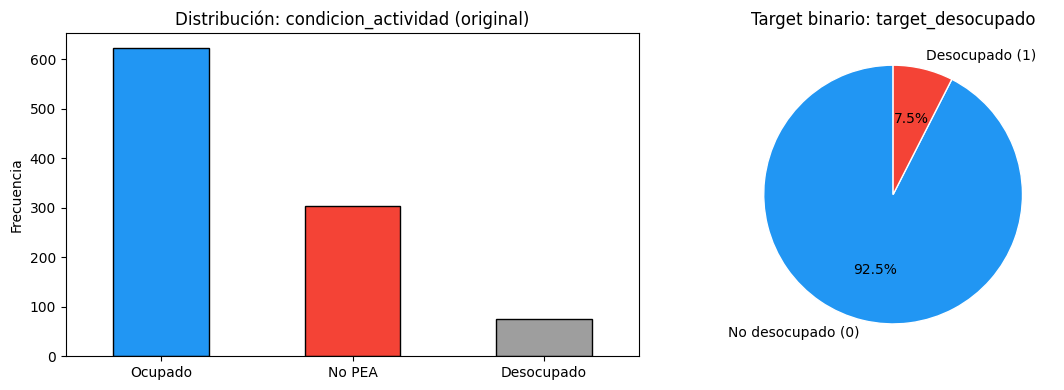

Gráfico guardado.


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribución del target original (3 clases)
df['condicion_actividad'].value_counts().plot(
    kind='bar', ax=axes[0], color=['#2196F3', '#F44336', '#9E9E9E'], edgecolor='black'
)
axes[0].set_title('Distribución: condicion_actividad (original)')
axes[0].set_xlabel('')
axes[0].set_ylabel('Frecuencia')
axes[0].tick_params(axis='x', rotation=0)

# Distribución del target binario
labels = ['No desocupado (0)', 'Desocupado (1)']
sizes = df['target_desocupado'].value_counts().sort_index().values
axes[1].pie(sizes, labels=labels, autopct='%1.1f%%', colors=['#2196F3', '#F44336'],
            startangle=90, wedgeprops={'edgecolor': 'white'})
axes[1].set_title('Target binario: target_desocupado')

plt.tight_layout()
plt.savefig(os.path.join('..', 'data', 'raw', 'target_distribution.png'), dpi=100, bbox_inches='tight')
plt.show()
print('Gráfico guardado.')

## 4. Análisis del desbalance de clases

Si la tasa de desocupación es inferior al 20%, el dataset estará desbalanceado y requerirá técnicas de balanceo en la etapa `04_class_balancing`.

In [4]:
tasa = df['target_desocupado'].mean()
print(f'Tasa de la clase minoritaria: {tasa*100:.2f}%')
if tasa < 0.20:
    print('⚠️  Dataset desbalanceado. Se recomienda aplicar técnicas de balanceo.')
else:
    print('✅  Las clases están suficientemente balanceadas.')

Tasa de la clase minoritaria: 7.50%
⚠️  Dataset desbalanceado. Se recomienda aplicar técnicas de balanceo.
